In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten
from keras import Sequential
from keras.datasets import mnist

# Check for GPU devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set TensorFlow to use a specific GPU, if available
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. TensorFlow will run on CPU.")

1 Physical GPUs, 1 Logical GPUs


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,002,698 (7.64 MB)

 Trainable params: 2,002,698 (7.64 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [6]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,770 (335.04 KB)

 Trainable params: 85,770 (335.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
history = model.fit(X_train, y_train, epochs=3, validation_split=0.2)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9289 - loss: 0.2505 - val_accuracy: 0.9672 - val_loss: 0.1070
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9750 - loss: 0.0819 - val_accuracy: 0.9777 - val_loss: 0.0733
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9814 - loss: 0.0622 - val_accuracy: 0.9820 - val_loss: 0.0653


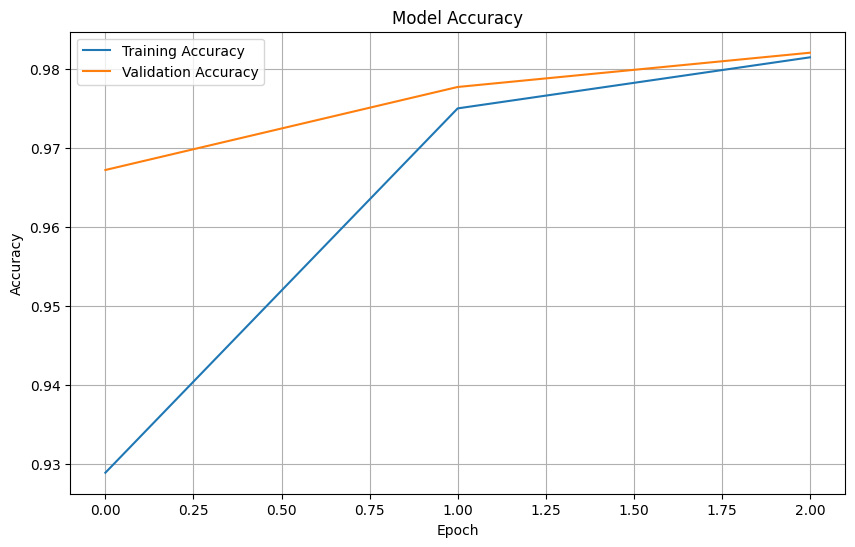

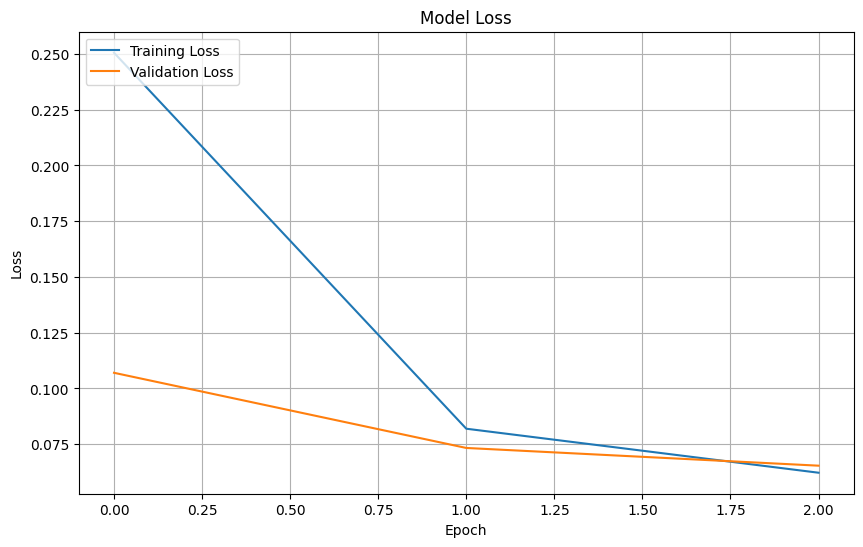

In [9]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')

313/313 - 2s - 6ms/step - accuracy: 0.9796 - loss: 0.0595
Test accuracy: 0.9796000123023987


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


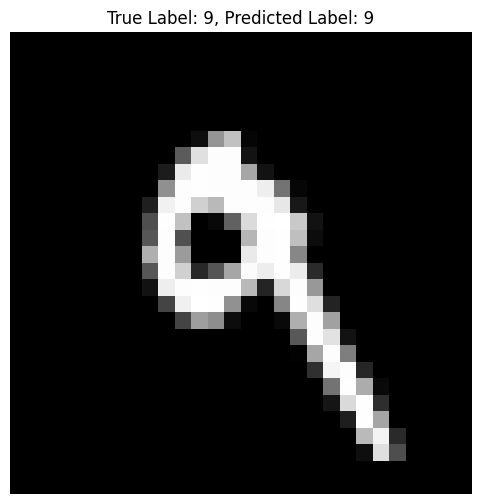

Confidence for predicted label 9: 1.00


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Select an image from the test set (e.g., the first one)
image_index = 7
selected_image = X_test[image_index]
true_label = y_test[image_index]

# Preprocess the image for prediction (add batch and channel dimensions)
# The model expects input shape (batch_size, height, width, channels)
# X_test is (num_samples, 28, 28) and the model expects (28, 28, 1) for a single image
input_image_for_model = np.expand_dims(selected_image, axis=0) # Add batch dimension
input_image_for_model = np.expand_dims(input_image_for_model, axis=-1) # Add channel dimension

# Make a prediction
predictions = model.predict(input_image_for_model)
predicted_label = np.argmax(predictions[0])

# Display the image and prediction
plt.figure(figsize=(6, 6))
plt.imshow(selected_image, cmap='gray')
plt.title(f'True Label: {true_label}, Predicted Label: {predicted_label}')
plt.axis('off')
plt.show()

print(f"Confidence for predicted label {predicted_label}: {predictions[0][predicted_label]:.2f}")

upload image:


Saving mnist_test_digit.png to mnist_test_digit (1).png


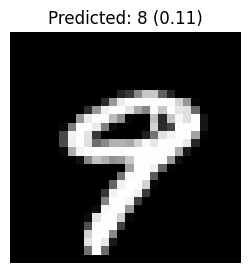

File Name: mnist_test_digit (1).png -> Model Prediction: 8



In [23]:
# Digit inference Function
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files # Google Colab mein file upload karne ke liye

print("upload image:")
#select from computer
uploaded = files.upload()

for file_name in uploaded.keys():
    # 2. Image ko grayscale (black and white) mein read karna
    raw_image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    # image invert
    if raw_image[0, 0] > 128:
        raw_image = cv2.bitwise_not(raw_image)

    # 4. PREPROCESSING: resize raw image
    resized_image = cv2.resize(raw_image, (28, 28))

    # 5. NORMALIZATION: Pixel values ko 0 se 1 ke beech lana
    normalized_image = resized_image.astype("float32") / 255.0

    # 6. DIMENSION ACCORDING TO MODEL: (1, 28, 28, 1) shape dena
    final_input = np.expand_dims(np.expand_dims(normalized_image, axis=0), axis=-1)

    # 7. MODEL DETECTION (using the trained model)
    predictions = model.predict(final_input, verbose=0)
    predicted_digit = np.argmax(predictions)
    confidence = predictions[0][predicted_digit]

    # 8. Result plot to screen
    plt.figure(figsize=(3, 3))
    plt.imshow(resized_image, cmap='gray')
    plt.title(f"Predicted: {predicted_digit} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

    print(f"File Name: {file_name} -> Model Prediction: {predicted_digit}\n")
